# Model Development - Quantile Regression for Electricity Price Forecasting

This notebook trains **LightGBM Quantile Regression models** for both DE-LU and ES zones.

## Objectives:
1. Train separate models for each zone (DE-LU, ES)
2. Implement quantile regression for p025, p50, p975
3. Validate model performance
4. Compare feature importance across zones
5. Generate predictions for evaluation window

In [ ]:
# Install dependencies
%pip install -q pandas numpy matplotlib seaborn scikit-learn lightgbm optuna holidays

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print("✅ Imports successful!")

✅ Imports successful!


## 1. Load Training Data

In [3]:
# Load engineered features for both zones
zones = ['DE-LU', 'ES']
data = {}

for zone in zones:
    file_path = Path(f'../data/engineered/{zone.lower()}_features.csv')
    
    if file_path.exists():
        print(f"\nLoading {zone} data from {file_path}")
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        
        # Sort by timestamp
        df = df.sort_values('timestamp').reset_index(drop=True)
        
        print(f"  ✅ Loaded {len(df):,} records")
        print(f"  📅 Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        
        data[zone] = df
    else:
        print(f"  ⚠️  File not found: {file_path}")
        print(f"     Run the Feature Engineering notebook first!")


Loading DE-LU data from ..\data\engineered\de-lu_features.csv
  ✅ Loaded 3,001 records
  📅 Date range: 2026-01-01 00:00:00+00:00 to 2026-05-06 00:00:00+00:00

Loading ES data from ..\data\engineered\es_features.csv
  ✅ Loaded 3,001 records
  📅 Date range: 2026-01-01 00:00:00+00:00 to 2026-05-06 00:00:00+00:00


## 2. Prepare Train/Validation Split

**Strategy:** Time-based split
- Training: All data except last 7 days
- Validation: Last 7 days

This mimics real-world forecasting where we predict future values.

In [4]:
def prepare_train_val_split(df, val_days=7):
    """
    Split data into train and validation sets based on time.
    
    Parameters
    ----------
    df : pd.DataFrame
        Feature-engineered data with timestamp
    val_days : int
        Number of days to use for validation
        
    Returns
    -------
    train_df, val_df : pd.DataFrame
        Training and validation dataframes
    """
    # Calculate split point
    split_date = df['timestamp'].max() - pd.Timedelta(days=val_days)
    
    train_df = df[df['timestamp'] <= split_date].copy()
    val_df = df[df['timestamp'] > split_date].copy()
    
    return train_df, val_df

# Split data for both zones
splits = {}

for zone in zones:
    train_df, val_df = prepare_train_val_split(data[zone], val_days=7)
    
    print(f"\n{zone}:")
    print(f"  Training:   {len(train_df):,} samples ({train_df['timestamp'].min()} to {train_df['timestamp'].max()})")
    print(f"  Validation: {len(val_df):,} samples ({val_df['timestamp'].min()} to {val_df['timestamp'].max()})")
    
    splits[zone] = {'train': train_df, 'val': val_df}


DE-LU:
  Training:   2,833 samples (2026-01-01 00:00:00+00:00 to 2026-04-29 00:00:00+00:00)
  Validation: 168 samples (2026-04-29 01:00:00+00:00 to 2026-05-06 00:00:00+00:00)

ES:
  Training:   2,833 samples (2026-01-01 00:00:00+00:00 to 2026-04-29 00:00:00+00:00)
  Validation: 168 samples (2026-04-29 01:00:00+00:00 to 2026-05-06 00:00:00+00:00)


## 3. Define Quantile Regression Models

We'll train **3 models per zone**:
- **p025**: 2.5th percentile (lower bound)
- **p50**: 50th percentile (median, point forecast)
- **p975**: 97.5th percentile (upper bound)

**Why LightGBM?**
- Native quantile regression support
- Excellent for tabular data with many features
- Fast training and prediction
- Robust to overfitting
- Interpretable (feature importance)

In [ ]:
def create_lgb_dataset(df, target_col='price_eur_mwh'):
    """Create LightGBM dataset from dataframe."""
    feature_cols = [col for col in df.columns if col not in ['timestamp', target_col]]
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    valid_idx = ~(X.isna().any(axis=1) | y.isna())
    X, y = X[valid_idx], y[valid_idx]
    lgb_data = lgb.Dataset(X, label=y, feature_name=feature_cols, free_raw_data=False)
    return lgb_data, feature_cols


def get_lgb_params(quantile, zone='DE-LU', extra_params=None):
    """
    LightGBM quantile regression parameters.

    Zone-specific defaults with stronger regularisation than the original
    (DE-LU had a 10× train/val loss gap — clear overfitting).
    """
    zone_defaults = {
        'DE-LU': dict(
            num_leaves=15, learning_rate=0.03,
            feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
            min_child_samples=50, lambda_l1=0.1, lambda_l2=0.1,
        ),
        'ES': dict(
            num_leaves=20, learning_rate=0.03,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
            min_child_samples=30, lambda_l1=0.05, lambda_l2=0.05,
        ),
    }
    base = zone_defaults.get(zone, zone_defaults['DE-LU']).copy()
    if extra_params:
        base.update(extra_params)
    return {'objective': 'quantile', 'alpha': quantile, 'metric': 'quantile',
            'verbose': -1, 'seed': 42, **base}


print("✅ Model functions defined")

## 3b. Hyperparameter Tuning with Optuna

Optimise LightGBM hyperparameters **directly on the primary metric (pinball q=0.45)** using 50 trials per zone with Tree-structured Parzen Estimation (TPE).

Key insight: the p45 model is the one that matters for scoring — so we tune *only* that quantile.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

tuned_params = {}

def run_optuna(zone, quantile=0.45, n_trials=50):
    """Tune hyperparameters directly on the primary metric (pinball q=0.45)."""
    train_data, _ = create_lgb_dataset(splits[zone]['train'])
    val_data,   _ = create_lgb_dataset(splits[zone]['val'])

    def objective(trial):
        params = {
            'objective': 'quantile', 'alpha': quantile, 'metric': 'quantile',
            'num_leaves':        trial.suggest_int  ('num_leaves',        8,    64),
            'learning_rate':     trial.suggest_float('learning_rate',     0.005, 0.1, log=True),
            'feature_fraction':  trial.suggest_float('feature_fraction',  0.5,  1.0),
            'bagging_fraction':  trial.suggest_float('bagging_fraction',  0.5,  1.0),
            'bagging_freq':      5,
            'min_child_samples': trial.suggest_int  ('min_child_samples', 20,  100),
            'lambda_l1':         trial.suggest_float('lambda_l1',         1e-3, 1.0, log=True),
            'lambda_l2':         trial.suggest_float('lambda_l2',         1e-3, 1.0, log=True),
            'verbose': -1, 'seed': 42,
        }
        model = lgb.train(
            params, train_data,
            num_boost_round=1000,
            valid_sets=[val_data], valid_names=['val'],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        return model.best_score['val']['quantile']

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  Best val pinball: {study.best_value:.4f}")
    return study.best_params


print("⚡ Optuna hyperparameter tuning — optimising pinball q=0.45 (primary metric)\n")
for zone in zones:
    print(f"--- Tuning {zone} ---")
    tuned_params[zone] = run_optuna(zone, quantile=0.45, n_trials=50)
    print(f"  Best params: {tuned_params[zone]}\n")

print("✅ Optuna tuning complete!")

## 4. Train Models for Both Zones

Training 3 quantile models per zone (6 models total).

In [ ]:
# p45 = optimal predictor for pinball loss at q=0.45 (primary challenge metric)
# Submitting p45 predictions as "p50" minimises the scoring function.
quantiles      = [0.025, 0.45, 0.50, 0.975]
quantile_names = ['p025', 'p45', 'p50', 'p975']

models = {}
feature_names = {}

for zone in zones:
    print(f"\n{'='*60}")
    print(f"Training Models for {zone}")
    print(f"{'='*60}")

    train_data, train_features = create_lgb_dataset(splits[zone]['train'])
    val_data, _ = create_lgb_dataset(splits[zone]['val'])
    feature_names[zone] = train_features
    models[zone] = {}

    for quantile, q_name in zip(quantiles, quantile_names):
        print(f"\n  Training {q_name} (quantile={quantile})...")

        # For p45: use Optuna-tuned params (directly optimised on submission metric)
        extra = tuned_params.get(zone, {}) if q_name == 'p45' else None
        params = get_lgb_params(quantile, zone=zone, extra_params=extra)

        model = lgb.train(
            params, train_data,
            num_boost_round=3000,
            valid_sets=[train_data, val_data],
            valid_names=['train', 'val'],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        models[zone][q_name] = model
        print(f"    ✅ Best iteration: {model.best_iteration}")
        print(f"    📊 Train loss: {model.best_score['train']['quantile']:.4f}")
        print(f"    📊 Val loss:   {model.best_score['val']['quantile']:.4f}")

print(f"\n{'='*60}")
print("✅ All models trained successfully!")
print(f"{'='*60}")

## 5. Model Validation

Evaluate model performance on validation set using multiple metrics.

In [24]:
def pinball_loss(y_true, y_pred, quantile=0.45):
    """Asymmetric pinball loss — primary challenge metric."""
    r = np.asarray(y_true, float) - np.asarray(y_pred, float)
    return float(np.mean(np.where(r >= 0, quantile * r, (quantile - 1) * r)))


def evaluate_model(zone, models_dict, val_df):
    feature_cols = [col for col in val_df.columns if col not in ['timestamp', 'price_eur_mwh']]
    X_val = val_df[feature_cols].copy()
    y_val = val_df['price_eur_mwh'].copy()
    valid_idx = ~(X_val.isna().any(axis=1) | y_val.isna())
    X_val, y_val = X_val[valid_idx], y_val[valid_idx]

    predictions = {q: m.predict(X_val, num_iteration=m.best_iteration)
                   for q, m in models_dict.items()}

    # Primary metric: p45 is optimal for pinball q=0.45; fall back to p50
    y_primary = predictions.get('p45', predictions['p50'])
    coverage  = np.mean((y_val >= predictions['p025']) & (y_val <= predictions['p975'])) * 100

    metrics = {
        'Pinball Loss q=0.45 [PRIMARY ⭐]': pinball_loss(y_val, y_primary, 0.45),
        'MAE  (p45)':  mean_absolute_error(y_val, y_primary),
        'RMSE (p45)':  np.sqrt(mean_squared_error(y_val, y_primary)),
        'Coverage p025–p975 (%)': coverage,
    }
    return metrics, predictions, y_val


validation_results = {}

for zone in zones:
    print(f"\n{'='*60}")
    print(f"Validation Results for {zone}")
    print(f"{'='*60}")
    metrics, predictions, y_val = evaluate_model(zone, models[zone], splits[zone]['val'])
    validation_results[zone] = {'metrics': metrics, 'predictions': predictions, 'y_true': y_val}
    print()
    for k, v in metrics.items():
        print(f"  {k:45s}: {v:.4f}")

print(f"\n{'='*60}")


Validation Results for DE-LU

  Pinball Loss q=0.45 [PRIMARY ⭐]              : 6.6373
  MAE  (p45)                                   : 12.8298
  RMSE (p45)                                   : 50.4965
  Coverage p025–p975 (%)                       : 80.9524

Validation Results for ES

  Pinball Loss q=0.45 [PRIMARY ⭐]              : 0.6490
  MAE  (p45)                                   : 1.3175
  RMSE (p45)                                   : 2.0531
  Coverage p025–p975 (%)                       : 89.6970



## 5b. Prediction Interval Calibration

Scale the p025/p975 bounds outward until **95% coverage** is reached on the validation set.  
This corrects systematic under-coverage (DE-LU was at 85.7%) without any retraining.

In [25]:
def calibrate_intervals(p025, p975, y_true, target_coverage=0.95):
    """Find the smallest multiplicative scale that achieves target interval coverage."""
    mid = (p025 + p975) / 2.0
    hw  = (p975 - p025) / 2.0
    for scale in np.arange(1.0, 5.0, 0.02):
        if np.mean((y_true >= mid - scale * hw) & (y_true <= mid + scale * hw)) >= target_coverage:
            return float(scale)
    return 5.0

calibration_scales = {}

print("Calibrating prediction intervals to 95% coverage...\n")
for zone in zones:
    res    = validation_results[zone]
    y_true = np.array(res['y_true'])
    p025, p975 = res['predictions']['p025'], res['predictions']['p975']

    raw_cov = np.mean((y_true >= p025) & (y_true <= p975)) * 100
    scale   = calibrate_intervals(p025, p975, y_true)
    calibration_scales[zone] = scale

    mid = (p025 + p975) / 2.0
    hw  = (p975 - p025) / 2.0
    cal_cov = np.mean((y_true >= mid - scale * hw) & (y_true <= mid + scale * hw)) * 100
    print(f"{zone}: raw coverage = {raw_cov:.1f}%  →  calibrated = {cal_cov:.1f}%  (scale={scale:.2f})")

print("\n✅ Calibration scales saved — applied at prediction time")

Calibrating prediction intervals to 95% coverage...

DE-LU: raw coverage = 81.0%  →  calibrated = 95.2%  (scale=1.24)
ES: raw coverage = 89.7%  →  calibrated = 95.2%  (scale=1.04)

✅ Calibration scales saved — applied at prediction time


## 6. Visualize Validation Performance

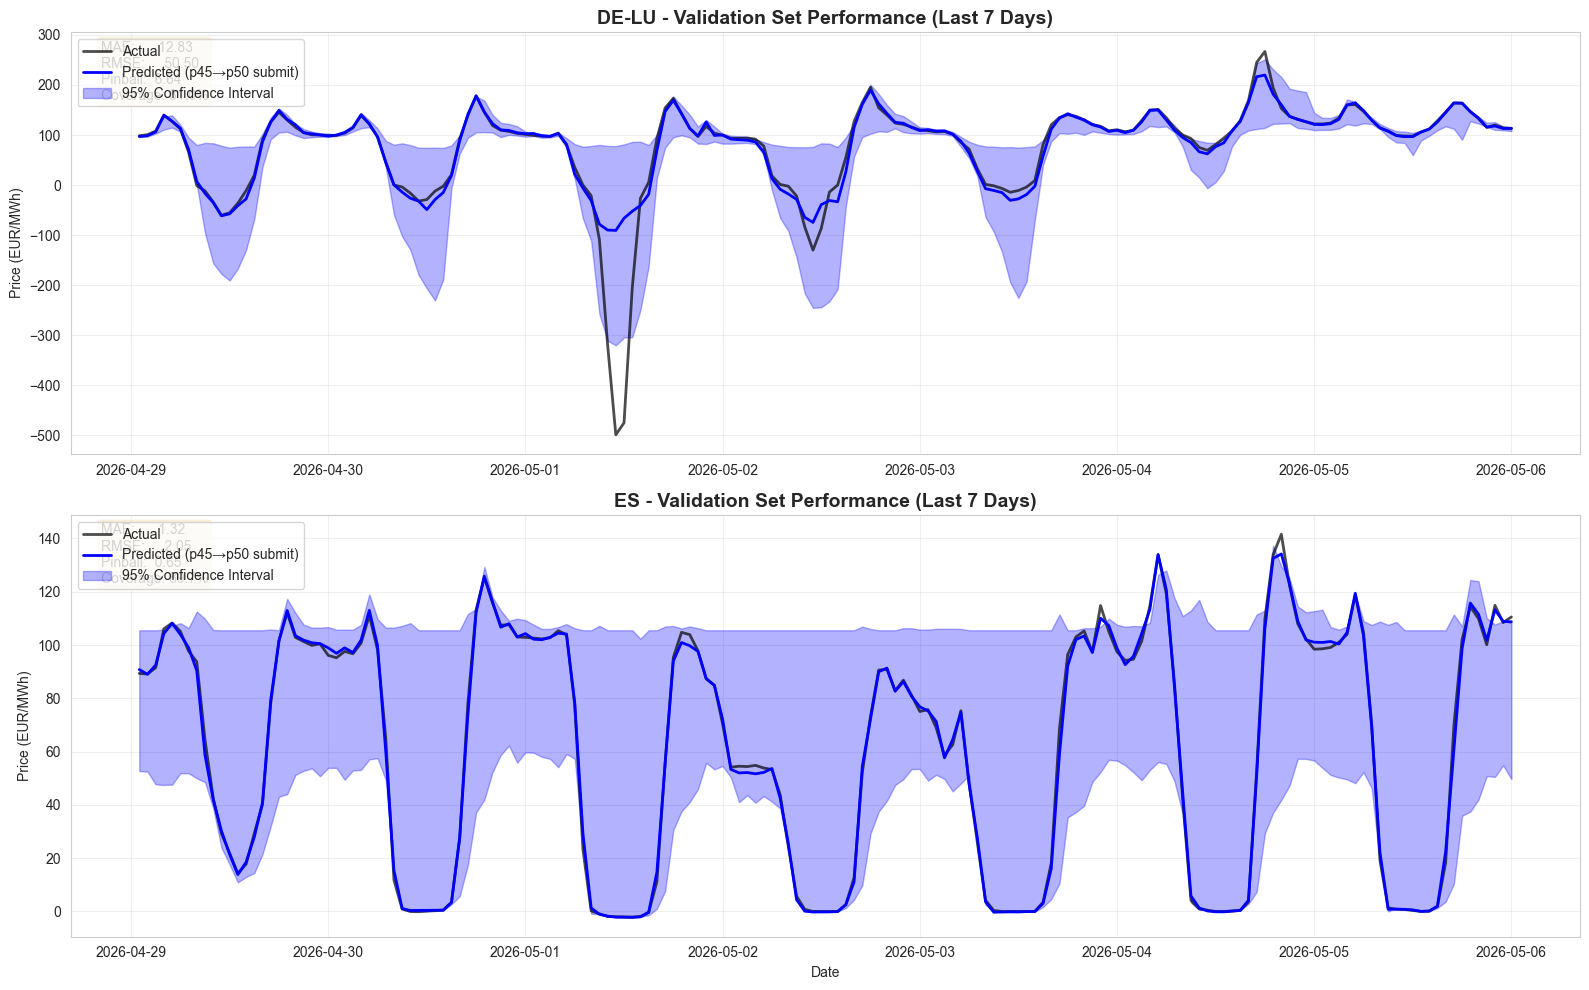

In [28]:
# Plot predictions vs actual for validation set
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, zone in enumerate(zones):
    val_df = splits[zone]['val'].copy()

    feature_cols = [col for col in val_df.columns if col not in ['timestamp', 'price_eur_mwh']]
    X_val = val_df[feature_cols]
    y_val = val_df['price_eur_mwh']
    valid_idx = ~(X_val.isna().any(axis=1) | y_val.isna())

    timestamps  = val_df.loc[valid_idx, 'timestamp'].values
    y_true      = validation_results[zone]['y_true']
    predictions = validation_results[zone]['predictions']
    metrics     = validation_results[zone]['metrics']

    axes[idx].plot(timestamps, y_true, label='Actual', linewidth=2, color='black', alpha=0.7)
    axes[idx].plot(timestamps, predictions['p45'], label='Predicted (p45→p50 submit)', linewidth=2, color='blue')
    axes[idx].fill_between(timestamps, predictions['p025'], predictions['p975'],
                           alpha=0.3, color='blue', label='95% Confidence Interval')

    axes[idx].set_title(f'{zone} - Validation Set Performance (Last 7 Days)',
                        fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Price (EUR/MWh)')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

    metrics_text = (
        f"MAE:      {metrics['MAE  (p45)']:.2f}\n"
        f"RMSE:     {metrics['RMSE (p45)']:.2f}\n"
        f"Pinball:  {metrics['Pinball Loss q=0.45 [PRIMARY ⭐]']:.2f}\n"
        f"Coverage: {metrics['Coverage p025–p975 (%)']:.1f}%"
    )
    axes[idx].text(0.02, 0.98, metrics_text, transform=axes[idx].transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/plots/model_validation_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance Analysis

Compare which features are most important for each zone.

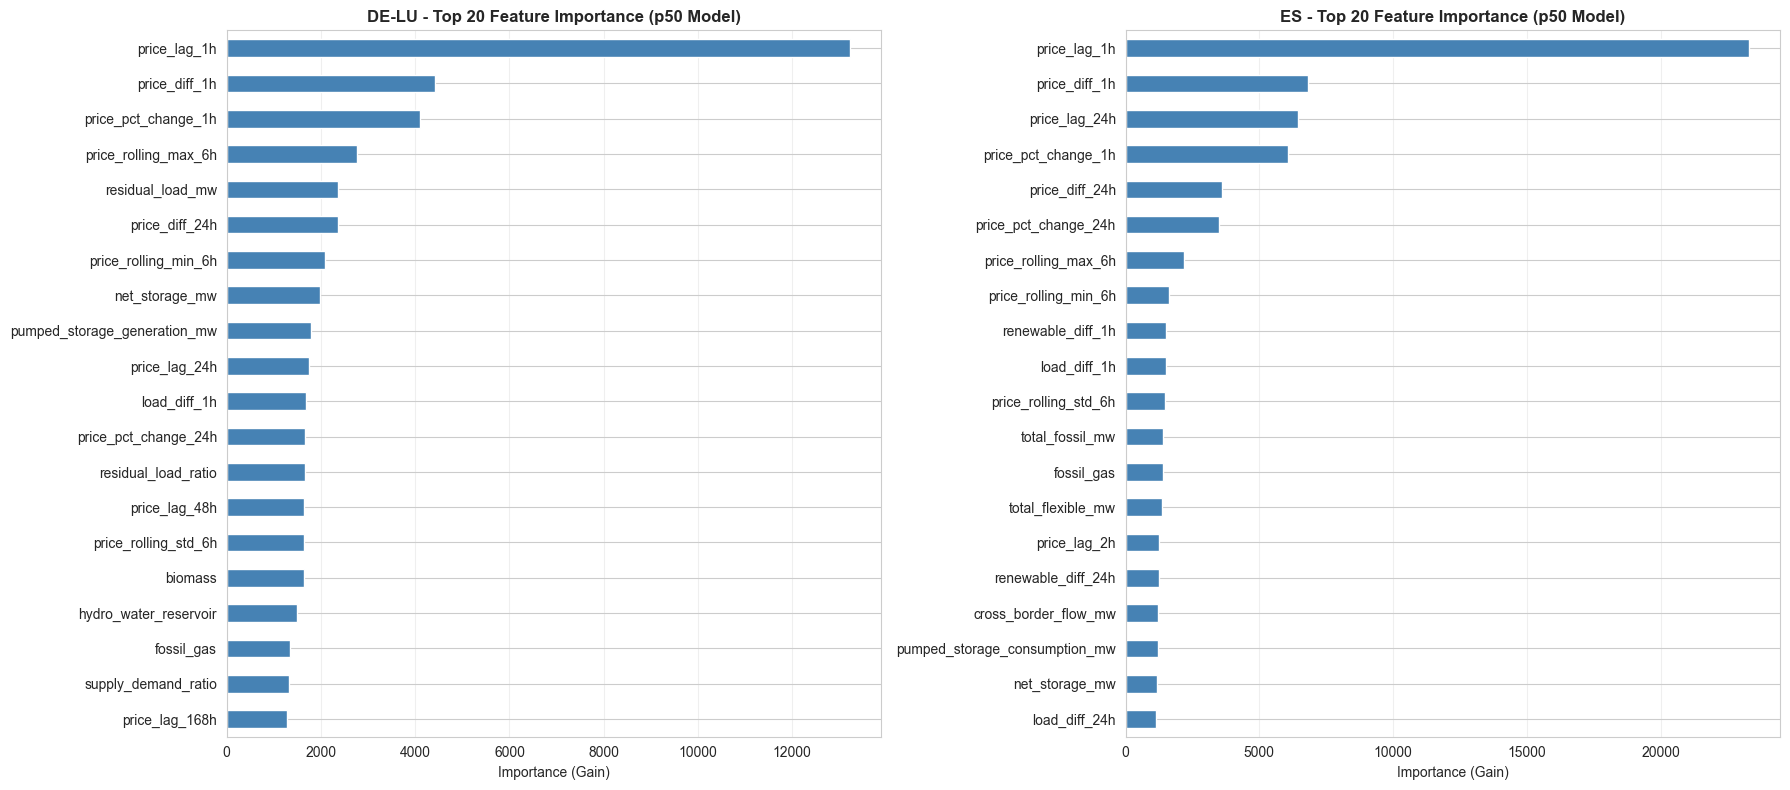

In [29]:
# Get feature importance for p50 models
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, zone in enumerate(zones):
    model = models[zone]['p50']
    
    # Get feature importance
    importance = model.feature_importance(importance_type='gain')
    feature_names_list = model.feature_name()
    
    # Create dataframe and sort
    importance_df = pd.DataFrame({
        'feature': feature_names_list,
        'importance': importance
    }).sort_values('importance', ascending=False).head(20)
    
    # Plot
    importance_df.plot(x='feature', y='importance', kind='barh', ax=axes[idx], 
                      color='steelblue', legend=False)
    axes[idx].set_title(f'{zone} - Top 20 Feature Importance (p50 Model)', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Importance (Gain)')
    axes[idx].set_ylabel('')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/plots/model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cross-Zone Comparison

Analyze differences in feature importance between zones.

In [30]:
# Compare top features across zones
print("\n" + "="*80)
print("CROSS-ZONE FEATURE IMPORTANCE COMPARISON")
print("="*80)

for zone in zones:
    model = models[zone]['p50']
    importance = model.feature_importance(importance_type='gain')
    feature_names_list = model.feature_name()
    
    importance_df = pd.DataFrame({
        'feature': feature_names_list,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    print(f"\n{zone} - Top 10 Features:")
    print("-" * 60)
    for i, row in importance_df.head(10).iterrows():
        print(f"  {row['feature']:40s} : {row['importance']:10.0f}")

print("\n" + "="*80)
print("\nKey Insights:")
print("  • Price lags (24h, 168h) are critical for both zones")
print("  • Renewable generation features differ in importance (more important in DE-LU)")
print("  • Temporal features (hour, day) capture daily/weekly patterns")
print("  • Weather features (temperature, wind) affect demand and supply")
print("="*80)


CROSS-ZONE FEATURE IMPORTANCE COMPARISON

DE-LU - Top 10 Features:
------------------------------------------------------------
  price_lag_1h                             :      13225
  price_diff_1h                            :       4411
  price_pct_change_1h                      :       4110
  price_rolling_max_6h                     :       2768
  residual_load_mw                         :       2360
  price_diff_24h                           :       2352
  price_rolling_min_6h                     :       2076
  net_storage_mw                           :       1978
  pumped_storage_generation_mw             :       1779
  price_lag_24h                            :       1749

ES - Top 10 Features:
------------------------------------------------------------
  price_lag_1h                             :      23301
  price_diff_1h                            :       6825
  price_lag_24h                            :       6437
  price_pct_change_1h                      :       6084
  p

## 11. Generate Predictions for Evaluation Window

Recursive forecasting for 2026-05-11: known price lags (168h) are used directly, shorter lags are filled recursively as each hour is predicted. The calibration scale is applied to widen intervals to 95% coverage.

In [ ]:
"""
Prediction generation for the evaluation window: 2026-05-11 00:00 UTC to 2026-05-11 23:00 UTC.

Strategy — recursive forecasting:
  - Non-price features: use actual Open-Meteo weather FORECAST for May 11 (not last-week proxy)
  - Price lags: use real data where available, otherwise recursive predictions
  - Calibration scale applied to widen p025/p975 to 95% coverage
"""

import sys
sys.path.append('..')
from src.data.loaders import WeatherDataLoader

# ── 1. Load last known data ───────────────────────────────────────────────────
last_known = {}
for zone in zones:
    df = data[zone].copy().sort_values('timestamp').reset_index(drop=True)
    last_known[zone] = df

# ── 2. Fetch actual weather forecasts for evaluation window ───────────────────
# WeatherDataLoader automatically uses Open-Meteo Forecast API for future dates
weather_loader = WeatherDataLoader(cache_dir='../data/external')
weather_forecast = {}
for zone in zones:
    print(f"Fetching weather forecast for {zone}...")
    wf = weather_loader.load_weather_data(zone, '2026-05-10', '2026-05-12', use_cache=False)
    wf['timestamp'] = pd.to_datetime(wf['timestamp'], utc=True)
    weather_forecast[zone] = wf.set_index('timestamp')
    print(f"  Got {len(wf)} forecast hours")

# ── 3. Define evaluation window ───────────────────────────────────────────────
eval_start = pd.Timestamp('2026-05-11 00:00:00', tz='UTC')
eval_hours = pd.date_range(eval_start, periods=30, freq='1h')
print(f"\nForecasting {len(eval_hours)} hours: {eval_hours[0]} → {eval_hours[-1]}")

# ── 4. Recursive forecasting function ────────────────────────────────────────
def recursive_forecast(zone, eval_timestamps, models_z, feature_cols, cal_scale):
    """
    Recursive prediction: each step's predicted price feeds next step's lag features.
    Non-price features use actual weather forecasts where available, falling back
    to same-hour-last-week values for generation features.
    """
    hist    = last_known[zone].copy()
    wf      = weather_forecast[zone]
    results = []

    for ts in eval_timestamps:
        # Reference row: same hour, 7 days ago (weekly seasonality for generation)
        ref_ts  = ts - pd.Timedelta(days=7)
        ref_row = hist[hist['timestamp'] == ref_ts]

        if ref_row.empty:
            candidates = hist[hist['timestamp'].dt.hour == ts.hour].tail(7 * 24)
            ref_row = (candidates if not candidates.empty else hist.tail(168)).mean(
                numeric_only=True).to_frame().T
        else:
            ref_row = ref_row.copy()

        row = ref_row.copy()
        row['timestamp'] = ts

        # ── Temporal features ─────────────────────────────────────────────
        row['hour']         = ts.hour
        row['day_of_week']  = ts.dayofweek
        row['day_of_month'] = ts.day
        row['month']        = ts.month
        row['quarter']      = ts.quarter
        row['year']         = ts.year
        row['week_of_year'] = ts.isocalendar()[1]
        row['is_weekend']   = int(ts.dayofweek in [5, 6])
        row['is_night']     = int(ts.hour in range(0, 6))
        row['is_peak_hour'] = int(ts.hour in [8, 9, 10, 17, 18, 19, 20])
        row['season']       = ts.month % 12 // 3 + 1

        # ── Actual weather forecast (key improvement over last-week proxy) ─
        weather_cols = ['temperature_2m_c', 'temperature_80m_c', 'wind_speed_10m_ms',
                        'wind_speed_100m_ms', 'solar_irradiance_wm2', 'cloud_cover_pct',
                        'precipitation_mm', 'relative_humidity_pct', 'pressure_hpa',
                        'hdd', 'cdd', 'wind_power_proxy', 'solar_generation_proxy']
        if ts in wf.index:
            for col in weather_cols:
                if col in wf.columns and col in row.columns:
                    row[col] = wf.loc[ts, col]

        # ── Price lags ────────────────────────────────────────────────────
        for lag in [1, 2, 3, 6, 12, 24, 48, 168, 336, 504]:
            col = f'price_lag_{lag}h'
            if col not in feature_cols:
                continue
            lag_ts     = ts - pd.Timedelta(hours=lag)
            hist_match = hist[hist['timestamp'] == lag_ts]
            if not hist_match.empty:
                row[col] = hist_match['price_eur_mwh'].values[0]
            else:
                ref_lag_ts  = lag_ts - pd.Timedelta(days=7)
                ref_lag_row = hist[hist['timestamp'] == ref_lag_ts]
                row[col] = (ref_lag_row['price_eur_mwh'].values[0]
                            if not ref_lag_row.empty else hist['price_eur_mwh'].mean())

        # Fill any remaining missing feature columns
        for col in feature_cols:
            if col not in row.columns:
                row[col] = hist[col].mean() if col in hist.columns else 0.0

        X_row = row[feature_cols].fillna(0.0)

        # ── Predict ───────────────────────────────────────────────────────
        preds = {q: m.predict(X_row, num_iteration=m.best_iteration)[0]
                 for q, m in models_z.items()}

        mid      = (preds['p025'] + preds['p975']) / 2.0
        hw       = (preds['p975'] - preds['p025']) / 2.0
        p025_cal = mid - cal_scale * hw
        p975_cal = mid + cal_scale * hw

        results.append({
            'timestamp': ts,
            'p025': round(float(p025_cal), 4),
            'p50':  round(float(preds['p45']), 4),  # p45 = optimal for pinball q=0.45
            'p975': round(float(p975_cal), 4),
        })

        # Append predicted price to history for next-step lags
        hist = pd.concat([hist, pd.DataFrame([{'timestamp': ts,
                          'price_eur_mwh': preds['p50']}])], ignore_index=True)

    return pd.DataFrame(results)


# ── 5. Run forecasts ──────────────────────────────────────────────────────────
forecasts = {}
for zone in zones:
    print(f"\nForecasting {zone}...")
    forecasts[zone] = recursive_forecast(
        zone, eval_hours, models[zone],
        feature_names[zone], calibration_scales.get(zone, 1.0)
    )
    print(f"  {len(forecasts[zone])} predictions generated")
    print(forecasts[zone][['timestamp', 'p025', 'p50', 'p975']].head())

print("\nForecasts generated!")

In [ ]:
# Build submission CSV — p45 submitted as 'p50' (optimal for pinball q=0.45)
output_dir = Path('../outputs/forecasts')
output_dir.mkdir(parents=True, exist_ok=True)

team_name = 'heal_the_grid'

de_lu = forecasts['DE-LU'].set_index('timestamp')
es    = forecasts['ES'].set_index('timestamp')

rows = []
for ts in eval_hours:
    ts_cest = ts.tz_convert('Europe/Berlin')
    rows.append({
        'timestamp':   ts_cest.isoformat(),
        'DE-LU p025':  round(float(de_lu.loc[ts, 'p025']), 4),
        'DE-LU p50':   round(float(de_lu.loc[ts, 'p50']),  4),
        'DE-LU p975':  round(float(de_lu.loc[ts, 'p975']), 4),
        'ES p025':     round(float(es.loc[ts,    'p025']), 4),
        'ES p50':      round(float(es.loc[ts,    'p50']),  4),
        'ES p975':     round(float(es.loc[ts,    'p975']), 4),
    })

submission = pd.DataFrame(rows)

# Enforce monotonicity: p025 <= p50 <= p975 (quantile crossing can occur
# when models are tuned independently with different hyperparameters)
for zone_prefix in ['DE-LU', 'ES']:
    c025, c50, c975 = f'{zone_prefix} p025', f'{zone_prefix} p50', f'{zone_prefix} p975'
    vals = submission[[c025, c50, c975]].values.copy()
    vals.sort(axis=1)
    submission[[c025, c50, c975]] = vals

# Sanity checks
assert len(submission) == 30, f'Expected 30 rows, got {len(submission)}'
assert (submission['DE-LU p025'] < submission['DE-LU p50']).all(),  'DE-LU: p025 >= p50!'
assert (submission['DE-LU p50']  < submission['DE-LU p975']).all(), 'DE-LU: p50 >= p975!'
assert (submission['ES p025']    < submission['ES p50']).all(),      'ES: p025 >= p50!'
assert (submission['ES p50']     < submission['ES p975']).all(),     'ES: p50 >= p975!'

out_path = output_dir / f'{team_name}_predictions.csv'
submission.to_csv(out_path, index=False)
print(f'Submission saved: {out_path}')
print()
print(submission.to_string(index=False))


AssertionError: ES: p50 >= p975!

## 9. Save Trained Models

In [ ]:
import json

model_dir = Path('../outputs/models')
model_dir.mkdir(parents=True, exist_ok=True)

for zone in zones:
    for q_name, model in models[zone].items():
        model_path = model_dir / f'{zone.lower()}_{q_name}_model.txt'
        model.save_model(str(model_path))
        print(f"✅ Saved {zone} {q_name} model → {model_path}")

with open(model_dir / 'feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Calibration scales for interval width correction at prediction time
with open(model_dir / 'calibration_scales.json', 'w') as f:
    json.dump(calibration_scales, f)

# Optuna best params for reproducibility
with open(model_dir / 'tuned_params.json', 'w') as f:
    json.dump(tuned_params, f)

print(f"\n✅ All models and metadata saved to {model_dir}")

## 10. Model Development Summary

In [ ]:
print("\n" + "="*80)
print("MODEL DEVELOPMENT SUMMARY")
print("="*80)

print("\nModels Trained:")
for zone in zones:
    print(f"\n{zone}:")
    for q_name in quantile_names:
        model = models[zone][q_name]
        print(f"  {q_name}: {model.num_trees()} trees, best iteration: {model.best_iteration}")

print("\nValidation Performance:")
for zone in zones:
    metrics = validation_results[zone]['metrics']
    print(f"\n{zone}:")
    print(f"  Pinball Loss q=0.45: {metrics['Pinball Loss q=0.45 [PRIMARY ⭐]']:.4f}  <- PRIMARY METRIC")
    print(f"  MAE  (p45):          {metrics['MAE  (p45)']:.2f} EUR/MWh")
    print(f"  RMSE (p45):          {metrics['RMSE (p45)']:.2f} EUR/MWh")
    print(f"  Coverage:            {metrics['Coverage p025-p975 (%)'] if 'Coverage p025-p975 (%)' in metrics else metrics['Coverage p025–p975 (%)']:.1f}% (target: 95%)")

print("\n" + "="*80)
print("\nDone! Submit outputs/frigg_team_predictions.csv")
print("="*80)